# Step 3 (K-Fold) — Constitutional Predictors of Participatory Democracy

**Design:**
- **Target:** `v2x_partipdem` (Participatory democracy, 0–1)
- **Features:** 14 constitutional dimension scores (from Step 2)
- **Evaluation:** 5-fold country-blocked cross-validation — countries are divided into 5
  groups; each group is held out once as the test set. Reported R² is the average across
  all 5 folds, so it does not depend on one lucky/unlucky random split.
- **Out-of-fold predictions:** every country gets a prediction from a model that never
  saw it, covering all 178 countries (vs. 36 in the single-split version).
- **Final model:** trained on all data for feature importances and SHAP.
- **Backsliding gap:** actual − predicted (OOF) for 2016–2023, all countries.

**Input:** `ccpc_axis_scores_llm.csv` + `vdem/vdem_data.csv`  
**Output:** `backsliding_gap_v2x_partipdem.csv`, `feature_importances_v2x_partipdem.csv`

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

/Users/rishithhakker/miniforge3/envs/qss20/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SCORES_PATH  = '../ccpc_axis_scores_llm.csv'
VDEM_PATH    = '../data/vdem/vdem_data.csv'
TARGET       = 'v2x_partipdem'
K            = 5          # number of country-blocked folds
RANDOM_STATE = 42
TEST_YEARS   = list(range(2016, 2024))

FEATURES = [
    'ccpc_civil_liberties',
    'ccpc_socioeconomic_rights',
    'ccpc_political_competition',
    'ccpc_legislative_autonomy',
    'ccpc_executive_constraints',
    'ccpc_judicial_independence',
    'ccpc_rule_of_law_due_process',
    'ccpc_institutional_accountability',
    'ccpc_emergency_powers_constraints',
    'ccpc_civilian_control_of_security',
    'ccpc_amendment_rigidity',
    'ccpc_federalism_decentralization',
    'ccpc_transparency_information_access',
    'ccpc_equality_gender_minority_indigenous',
]

LABELS = {
    'ccpc_civil_liberties':                     'Civil liberties',
    'ccpc_socioeconomic_rights':                'Socioeconomic rights',
    'ccpc_political_competition':               'Political competition',
    'ccpc_legislative_autonomy':                'Legislative autonomy',
    'ccpc_executive_constraints':               'Executive constraints',
    'ccpc_judicial_independence':               'Judicial independence',
    'ccpc_rule_of_law_due_process':             'Rule of law / due process',
    'ccpc_institutional_accountability':        'Institutional accountability',
    'ccpc_emergency_powers_constraints':        'Emergency powers constraints',
    'ccpc_civilian_control_of_security':        'Civilian control of security',
    'ccpc_amendment_rigidity':                  'Amendment rigidity',
    'ccpc_federalism_decentralization':         'Federalism / decentralization',
    'ccpc_transparency_information_access':     'Transparency / info access',
    'ccpc_equality_gender_minority_indigenous': 'Equality (gender/minority/indigenous)',
}

print(f'Features : {len(FEATURES)}')
print(f'K        : {K} folds  (~{100//K}% test each round)')

Features : 14
K        : 5 folds  (~20% test each round)


## 1 — Load and Merge

In [3]:
ccpc = pd.read_csv(SCORES_PATH)
ccpc['cowcode'] = pd.to_numeric(ccpc['cowcode'], errors='coerce').astype('Int64')
ccpc['year']    = pd.to_numeric(ccpc['year'],    errors='coerce').astype('Int64')

vdem = pd.read_csv(VDEM_PATH, usecols=['country_name', 'country_text_id', 'COWcode', 'year', 'v2x_partipdem'])
vdem['COWcode'] = pd.to_numeric(vdem['COWcode'], errors='coerce').astype('Int64')

df = vdem.merge(
    ccpc[['cowcode', 'year'] + FEATURES],
    left_on=['COWcode', 'year'], right_on=['cowcode', 'year'],
    how='inner'
).drop(columns=['cowcode'])

df = df.dropna(subset=[TARGET])
df = df.dropna(subset=FEATURES, how='all')
df = df.reset_index(drop=True)

print(f'Rows: {len(df):,} | Countries: {df["COWcode"].nunique()} | Years: {df["year"].min()}–{df["year"].max()}')

Rows: 13,155 | Countries: 177 | Years: 1789–2023


## 2 — 5-Fold Country-Blocked Cross-Validation

`GroupKFold` ensures every country-year row from a given country lands in the same fold,
so no country leaks between train and test. With K=5, each fold holds out ~20% of
countries — the same proportion as the old single split, but repeated 5 times with
different countries each time. The average R² across folds is split-independent.

In [4]:
gkf     = GroupKFold(n_splits=K)
groups  = df['COWcode'].values

oof_preds  = np.full(len(df), np.nan)   # out-of-fold predictions for every row
fold_r2s   = []
fold_rmses = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups)):
    train_fold = df.iloc[train_idx]
    test_fold  = df.iloc[test_idx]

    m = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=3,
        l2_leaf_reg=5,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=0,
        early_stopping_rounds=30,
    )
    m.fit(
        train_fold[FEATURES], train_fold[TARGET],
        eval_set=(test_fold[FEATURES], test_fold[TARGET]),
    )

    preds = m.predict(test_fold[FEATURES])
    oof_preds[test_idx] = preds

    r2   = r2_score(test_fold[TARGET], preds)
    rmse = mean_squared_error(test_fold[TARGET], preds) ** 0.5
    fold_r2s.append(r2)
    fold_rmses.append(rmse)

    n_test_countries = test_fold['COWcode'].nunique()
    print(f'Fold {fold+1}: {n_test_countries:3d} test countries | R² = {r2:.4f} | RMSE = {rmse:.4f}')

cv_r2   = np.mean(fold_r2s)
cv_std  = np.std(fold_r2s)
cv_rmse = np.mean(fold_rmses)

# Overall OOF R² treats all predictions together (slightly different from fold average)
oof_r2 = r2_score(df[TARGET], oof_preds)

print(f'\nFold-average R²  : {cv_r2:.4f} ± {cv_std:.4f}')
print(f'Overall OOF R²   : {oof_r2:.4f}  (all predictions pooled)')
print(f'Fold-average RMSE: {cv_rmse:.4f}')

Fold 1:  35 test countries | R² = 0.0924 | RMSE = 0.1803
Fold 2:  36 test countries | R² = 0.0321 | RMSE = 0.1915


Fold 3:  35 test countries | R² = 0.1655 | RMSE = 0.1823
Fold 4:  36 test countries | R² = -0.0734 | RMSE = 0.2199


Fold 5:  35 test countries | R² = 0.0966 | RMSE = 0.1901

Fold-average R²  : 0.0626 ± 0.0800
Overall OOF R²   : 0.0720  (all predictions pooled)
Fold-average RMSE: 0.1928


## 3 — Final Model (all data) for Feature Importances & SHAP

The CV loop produces stable R² estimates but no single canonical model.
We train one more model on all data for feature importances and SHAP.

In [5]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=3,
    l2_leaf_reg=5,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=100,
)
model.fit(df[FEATURES], df[TARGET])
print(f'Final model trained on {len(df):,} rows ({df["COWcode"].nunique()} countries)')

0:	learn: 0.1989069	total: 10.2ms	remaining: 10.1s


100:	learn: 0.1430883	total: 321ms	remaining: 2.85s


200:	learn: 0.1230396	total: 640ms	remaining: 2.54s


300:	learn: 0.1073221	total: 961ms	remaining: 2.23s


400:	learn: 0.0976864	total: 1.26s	remaining: 1.89s


...

600:	learn: 0.0849897	total: 1.87s	remaining: 1.24s


700:	learn: 0.0803144	total: 2.21s	remaining: 944ms


800:	learn: 0.0763060	total: 2.46s	remaining: 611ms


900:	learn: 0.0729026	total: 2.68s	remaining: 294ms


999:	learn: 0.0702413	total: 2.91s	remaining: 0us
Final model trained on 13,155 rows (177 countries)


## 4 — Feature Importances

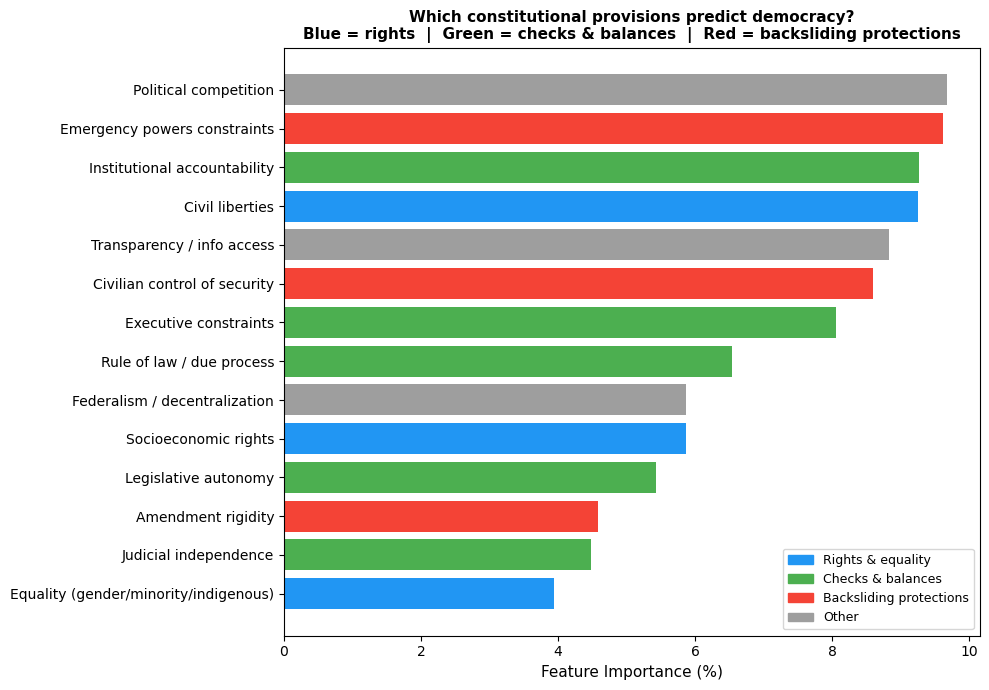

                                label  importance
                Political competition    9.671792
         Emergency powers constraints    9.621613
         Institutional accountability    9.272630
                      Civil liberties    9.246777
           Transparency / info access    8.828868
         Civilian control of security    8.588782
                Executive constraints    8.059163
            Rule of law / due process    6.536610
        Federalism / decentralization    5.869039
                 Socioeconomic rights    5.860990
                 Legislative autonomy    5.434254
                   Amendment rigidity    4.580014
                Judicial independence    4.483239
Equality (gender/minority/indigenous)    3.946230


In [6]:
feat_imp = (
    pd.DataFrame({'feature': FEATURES,
                  'importance': model.get_feature_importance()})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feat_imp['label'] = feat_imp['feature'].map(LABELS)

RIGHTS  = {'ccpc_civil_liberties', 'ccpc_socioeconomic_rights',
           'ccpc_equality_gender_minority_indigenous'}
CHECKS  = {'ccpc_executive_constraints', 'ccpc_judicial_independence',
           'ccpc_legislative_autonomy', 'ccpc_institutional_accountability',
           'ccpc_rule_of_law_due_process'}
PROTECT = {'ccpc_emergency_powers_constraints', 'ccpc_amendment_rigidity',
           'ccpc_civilian_control_of_security'}

def bar_color(f):
    if f in RIGHTS:  return '#2196F3'
    if f in CHECKS:  return '#4CAF50'
    if f in PROTECT: return '#F44336'
    return '#9E9E9E'

colors = [bar_color(f) for f in feat_imp['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp['label'], feat_imp['importance'], color=colors)
ax.set_xlabel('Feature Importance (%)', fontsize=11)
ax.set_title(
    'Which constitutional provisions predict democracy?\n'
    'Blue = rights  |  Green = checks & balances  |  Red = backsliding protections',
    fontsize=11, fontweight='bold'
)
ax.invert_yaxis()
legend_handles = [
    mpatches.Patch(color='#2196F3', label='Rights & equality'),
    mpatches.Patch(color='#4CAF50', label='Checks & balances'),
    mpatches.Patch(color='#F44336', label='Backsliding protections'),
    mpatches.Patch(color='#9E9E9E', label='Other'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print(feat_imp[['label', 'importance']].to_string(index=False))

## 5 — SHAP Analysis

SHAP values from the final model trained on all data — shows how each
constitutional feature shifts the predicted democracy score.

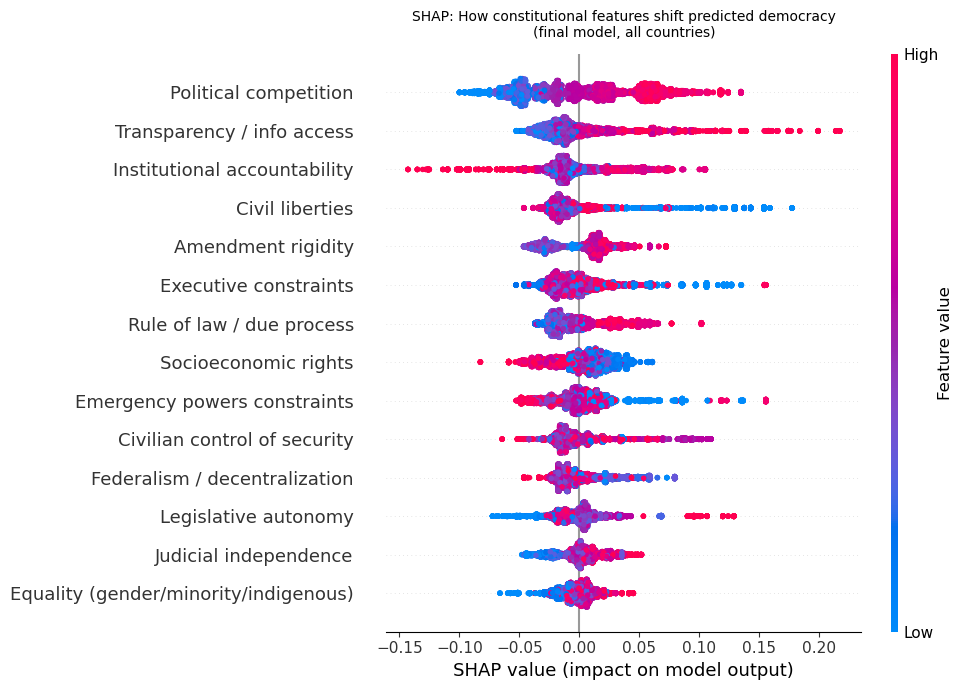

In [7]:
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(df[FEATURES])

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals,
    df[FEATURES].rename(columns=LABELS),
    feature_names=[LABELS[f] for f in FEATURES],
    show=False,
    plot_size=(10, 7),
)
plt.title(
    'SHAP: How constitutional features shift predicted democracy\n'
    '(final model, all countries)',
    fontsize=10, pad=12
)
plt.tight_layout()
plt.show()

## 5b — Interpretability: Direction & Shape of Each Feature

**Signed SHAP bar** — which features push predictions toward *more* vs *less* democracy on average.

**SHAP dependence plots** — one panel per feature. X = constitutional score (0–1), Y = SHAP value (contribution to prediction). The shape of the cloud + trend line reveals:
- Flat → feature has no effect
- Rising → higher constitutional score → higher predicted democracy (positive, roughly linear)
- Falling → negative relationship
- Curved → non-linear (U-shaped, threshold, diminishing returns)

> **Note on depth:** The CV + gap model uses `depth=3`. Below we also train a deeper (`depth=5`) model on all data **purely for visual exploration** of non-linear shapes — it is not used for the gap scores.

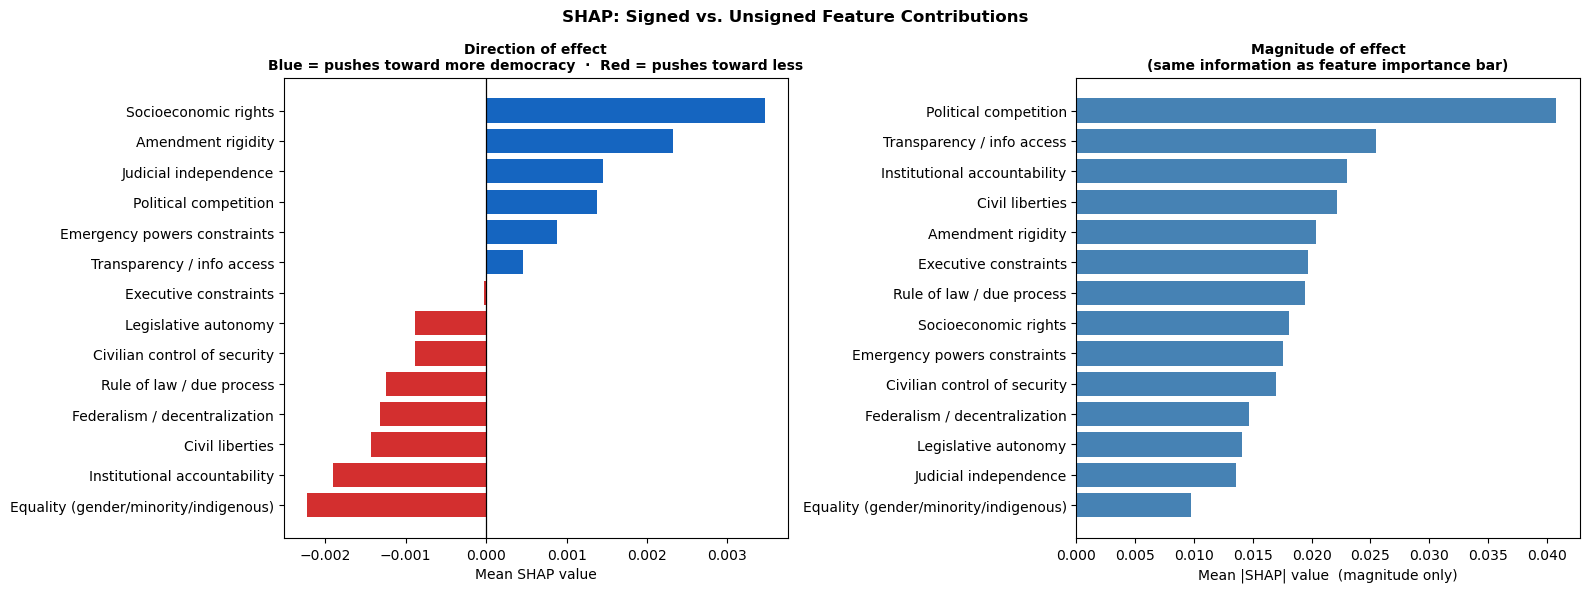


Signed mean SHAP per feature (sorted):
                                label  mean_shap  abs_shap
Equality (gender/minority/indigenous)  -0.002231  0.009706
         Institutional accountability  -0.001900  0.023042
                      Civil liberties  -0.001431  0.022126
        Federalism / decentralization  -0.001325  0.014640
            Rule of law / due process  -0.001251  0.019450
         Civilian control of security  -0.000891  0.016982
                 Legislative autonomy  -0.000890  0.014067
                Executive constraints  -0.000027  0.019659
           Transparency / info access   0.000458  0.025475
         Emergency powers constraints   0.000877  0.017570
                Political competition   0.001372  0.040776
                Judicial independence   0.001450  0.013594
                   Amendment rigidity   0.002326  0.020378
                 Socioeconomic rights   0.003462  0.018085


In [8]:
# ── Signed mean SHAP — direction of each feature ──────────────────────────────
# shap_vals[:, i] is positive when feature i pushes the prediction UP (more democracy)
# Taking the mean across all rows gives the average direction, not just magnitude.

mean_shap  = shap_vals.mean(axis=0)          # shape: (14,) — can be negative
abs_shap   = np.abs(shap_vals).mean(axis=0)  # magnitude (same as importance bar)

signed_df = (
    pd.DataFrame({'feature': FEATURES, 'mean_shap': mean_shap, 'abs_shap': abs_shap})
    .sort_values('mean_shap')
)
signed_df['label'] = signed_df['feature'].map(LABELS)
bar_colors = ['#d32f2f' if v < 0 else '#1565c0' for v in signed_df['mean_shap']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: signed mean SHAP
axes[0].barh(signed_df['label'], signed_df['mean_shap'], color=bar_colors)
axes[0].axvline(0, color='black', linewidth=0.9)
axes[0].set_xlabel('Mean SHAP value', fontsize=10)
axes[0].set_title(
    'Direction of effect\n'
    'Blue = pushes toward more democracy  ·  Red = pushes toward less',
    fontsize=10, fontweight='bold'
)

# Right: absolute mean SHAP (importance, for comparison)
imp_df = signed_df.sort_values('abs_shap')
axes[1].barh(imp_df['label'], imp_df['abs_shap'], color='steelblue')
axes[1].set_xlabel('Mean |SHAP| value  (magnitude only)', fontsize=10)
axes[1].set_title('Magnitude of effect\n(same information as feature importance bar)', fontsize=10, fontweight='bold')

plt.suptitle('SHAP: Signed vs. Unsigned Feature Contributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSigned mean SHAP per feature (sorted):')
print(signed_df[['label', 'mean_shap', 'abs_shap']].to_string(index=False))


### SHAP Dependence Plots (deeper model for shape visibility)

In [9]:
# ── Train a deeper model for shape exploration only ────────────────────────────
# depth=5 can represent more complex relationships; not used for gap scores.
model_deep = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=0,
)
model_deep.fit(df[FEATURES], df[TARGET])

explainer_deep = shap.TreeExplainer(model_deep)
shap_deep      = explainer_deep.shap_values(df[FEATURES])
print('Deep model trained. SHAP values computed.')
print(f'Train R² (deep, in-sample): {model_deep.score(df[FEATURES], df[TARGET]):.4f}')
print('(In-sample R² will be inflated — this model is for shape exploration only)')


Deep model trained. SHAP values computed.
Train R² (deep, in-sample): 0.9029
(In-sample R² will be inflated — this model is for shape exploration only)


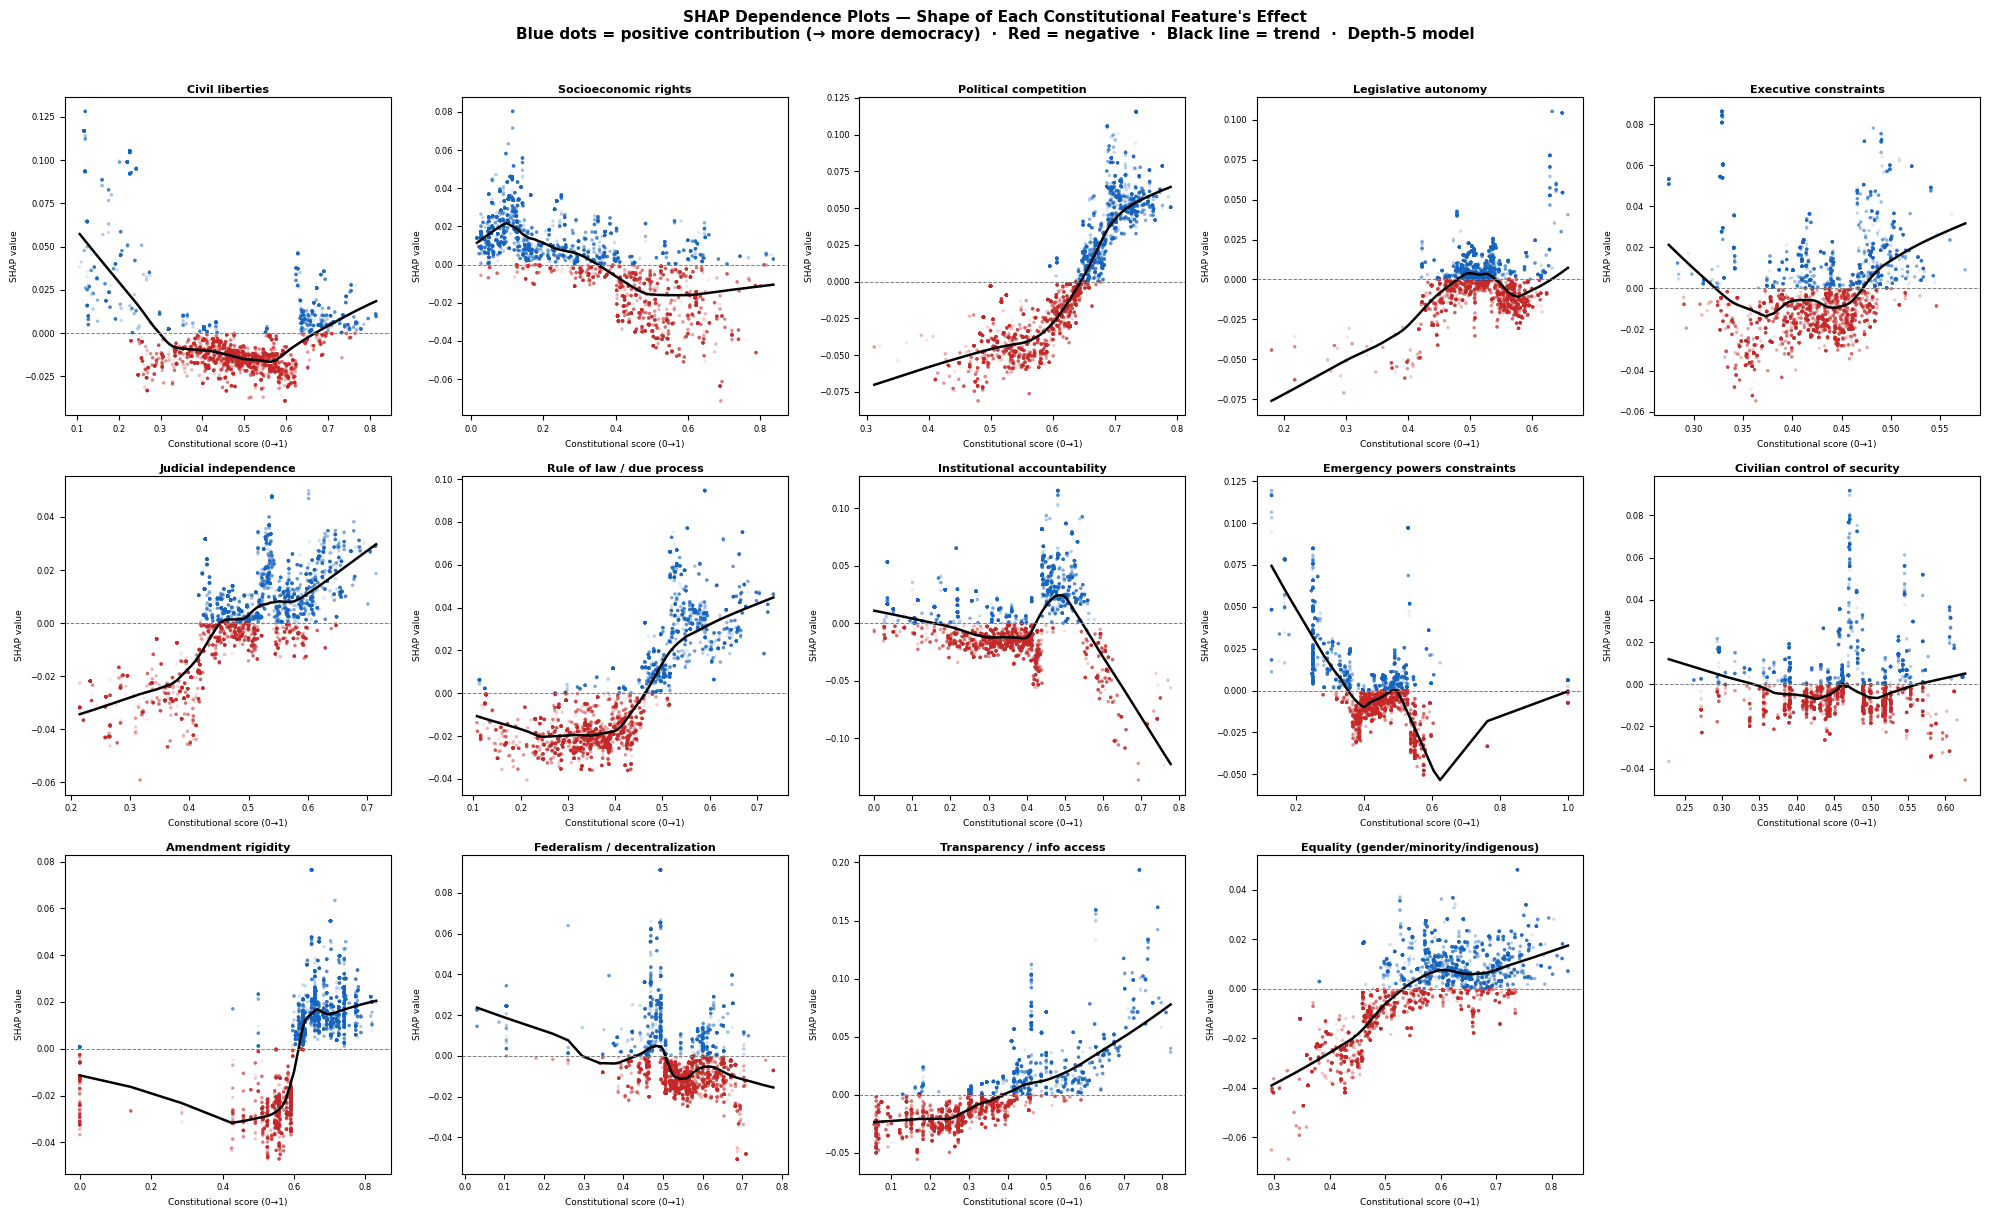

In [10]:
# ── SHAP dependence plots — one panel per feature ──────────────────────────────
# X = raw constitutional dimension score  (0 = weak, 1 = strong)
# Y = SHAP contribution to predicted democracy
# Shape reveals: linear / monotone / U-shaped / threshold / no effect

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except ImportError:
    HAS_LOWESS = False
    print('statsmodels not found — trend lines will use degree-3 polynomial instead')

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()

feat_vals_arr = df[FEATURES].values  # (n_rows, 14)

for i, feat in enumerate(FEATURES):
    ax       = axes_flat[i]
    x        = feat_vals_arr[:, i]
    y        = shap_deep[:, i]
    valid    = ~np.isnan(x)

    # scatter — colour by sign of SHAP
    point_colors = np.where(y > 0, '#1565c0', '#c62828')
    ax.scatter(x[valid], y[valid], c=point_colors[valid],
               alpha=0.12, s=6, linewidths=0)

    # trend line
    if valid.sum() > 20:
        if HAS_LOWESS:
            smooth = lowess(y[valid], x[valid], frac=0.4, return_sorted=True)
            ax.plot(smooth[:, 0], smooth[:, 1], color='black', lw=1.8, label='LOWESS')
        else:
            xv, yv = x[valid], y[valid]
            order   = np.argsort(xv)
            coeffs  = np.polyfit(xv[order], yv[order], 3)
            xfit    = np.linspace(xv.min(), xv.max(), 200)
            ax.plot(xfit, np.polyval(coeffs, xfit), color='black', lw=1.8)

    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.set_title(LABELS[feat], fontsize=8, fontweight='bold', pad=3)
    ax.set_xlabel('Constitutional score (0→1)', fontsize=6.5)
    ax.set_ylabel('SHAP value', fontsize=6.5)
    ax.tick_params(labelsize=6)

# hide the unused 15th panel (14 features in a 3×5 grid)
axes_flat[14].set_visible(False)

fig.suptitle(
    'SHAP Dependence Plots — Shape of Each Constitutional Feature\'s Effect\n'
    'Blue dots = positive contribution (→ more democracy)  ·  Red = negative  ·  '
    'Black line = trend  ·  Depth-5 model',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


## 6 — Backsliding Gap (2016–2023)

Uses **out-of-fold predictions** — each country's prediction came from a model
that never saw that country, so there is no leakage.
Because every country has an OOF prediction, this covers all countries
(not just the 36-country test subset from the old single split).

- **Negative residual** → democracy below what constitutional design predicts → backsliding signal
- **Positive residual** → more democratic than constitution predicts → institutional resilience

In [11]:
df = df.copy()
df['pred']     = oof_preds
df['residual'] = df[TARGET] - df['pred']

gap = (
    df[df['year'].isin(TEST_YEARS)]
    .groupby('country_name')[['v2x_partipdem', 'pred', 'residual']]
    .mean()
    .sort_values('residual')
    .round(3)
)
gap.columns = ['Actual (avg)', 'Predicted (avg)', 'Residual (avg)']

pd.set_option('display.float_format', '{:.3f}'.format)

print('=' * 65)
print('WORST BACKSLIDERS  (actual democracy well below predicted)')
print('=' * 65)
print(gap.head(12).to_string())

print('\n' + '=' * 65)
print('MOST RESILIENT  (actual democracy above predicted)')
print('=' * 65)
print(gap.tail(12).to_string())

WORST BACKSLIDERS  (actual democracy well below predicted)
                      Actual (avg)  Predicted (avg)  Residual (avg)
country_name                                                       
Eritrea                      0.010            0.291          -0.281
Nicaragua                    0.128            0.398          -0.270
Uzbekistan                   0.055            0.300          -0.245
Cuba                         0.052            0.293          -0.242
Angola                       0.088            0.306          -0.218
Ethiopia                     0.137            0.339          -0.202
Tajikistan                   0.055            0.253          -0.198
United Arab Emirates         0.030            0.227          -0.197
China                        0.037            0.230          -0.193
Morocco                      0.160            0.352          -0.192
Saudi Arabia                 0.024            0.215          -0.191
Venezuela                    0.162            0.348      

## 7 — Scatter: Predicted vs. Actual (2023)

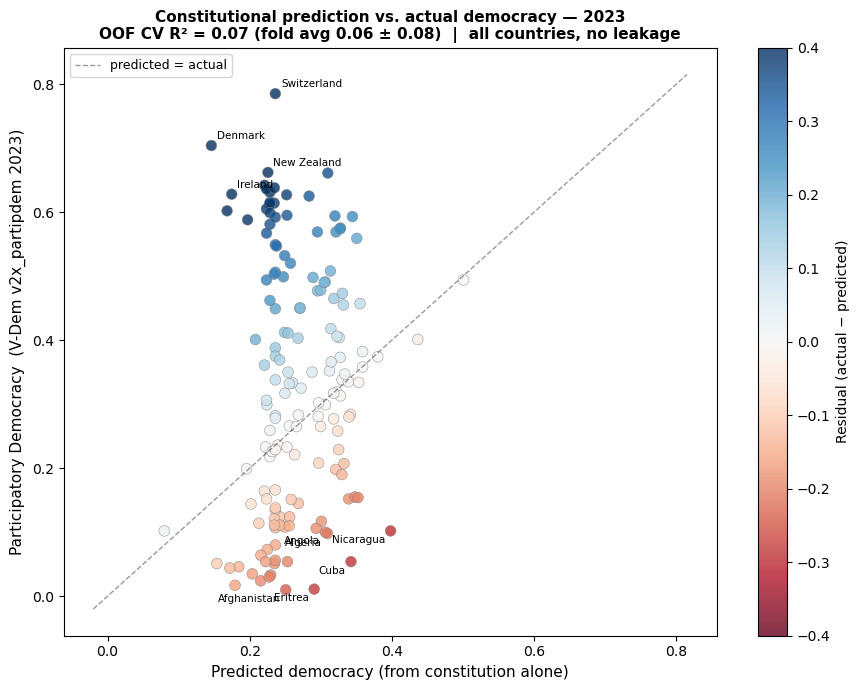

In [12]:
gap_2023 = df[df['year'] == 2023].copy()

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    gap_2023['pred'], gap_2023[TARGET],
    c=gap_2023['residual'], cmap='RdBu', vmin=-0.4, vmax=0.4,
    s=60, alpha=0.8, linewidths=0.4, edgecolors='grey'
)
plt.colorbar(sc, ax=ax, label='Residual (actual − predicted)')

lo = min(gap_2023['pred'].min(), gap_2023[TARGET].min()) - 0.03
hi = max(gap_2023['pred'].max(), gap_2023[TARGET].max()) + 0.03
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.4, label='predicted = actual')

sorted_gap = gap_2023.sort_values('residual')
for _, row in sorted_gap.head(6).iterrows():
    ax.annotate(row['country_name'], (row['pred'], row[TARGET]),
                fontsize=7.5, ha='right', va='top',
                xytext=(-4, -3), textcoords='offset points')
for _, row in sorted_gap.tail(4).iterrows():
    ax.annotate(row['country_name'], (row['pred'], row[TARGET]),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points')

ax.set_xlabel('Predicted democracy (from constitution alone)', fontsize=11)
ax.set_ylabel('Participatory Democracy  (V-Dem v2x_partipdem 2023)', fontsize=11)
ax.set_title(
    f'Constitutional prediction vs. actual democracy — 2023\n'
    f'OOF CV R² = {oof_r2:.2f} (fold avg {cv_r2:.2f} ± {cv_std:.2f})  |  all countries, no leakage',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8 — World Map: Actual Democracy Score (2023)

V-Dem `v2x_partipdem` score as measured — how democratic each country actually is.

In [13]:
fig = go.Figure(go.Choropleth(
    locations=gap_2023['country_text_id'].str.upper(),
    z=gap_2023['v2x_partipdem'].round(3),
    text=gap_2023['country_name'],
    customdata=gap_2023[['v2x_partipdem']].values,
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Actual democracy: <b>%{z:.3f}</b><extra></extra>'
    ),
    colorscale='RdBu',
    zmin=0, zmax=1,
    colorbar=dict(title='V-Dem<br>v2x_partipdem', tickformat='.2f', len=0.75),
    marker_line_width=0.4,
))
fig.update_layout(
    title=dict(
        text=(
            'Actual Democracy Score — 2023  (V-Dem v2x_partipdem)<br>'
            '<sub>Green = more democratic  ·  Red = less democratic</sub>'
        ),
        x=0.5
    ),
    geo=dict(showframe=False, projection_type='natural earth', bgcolor='#f9f9f9'),
    height=540, margin=dict(l=0, r=0, t=70, b=0)
)
fig.show()

## 9 — World Map: Constitutional Prediction (2023)

How democratic each country *ought to be* based on its constitutional design alone —
the OOF model prediction. Same color scale as Map 8 for direct comparison.

In [14]:
fig = go.Figure(go.Choropleth(
    locations=gap_2023['country_text_id'].str.upper(),
    z=gap_2023['pred'].round(3),
    text=gap_2023['country_name'],
    customdata=gap_2023[['pred']].values,
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Constitutional prediction: <b>%{z:.3f}</b><extra></extra>'
    ),
    colorscale='RdBu',
    zmin=0, zmax=1,
    colorbar=dict(title='Predicted<br>democracy', tickformat='.2f', len=0.75),
    marker_line_width=0.4,
))
fig.update_layout(
    title=dict(
        text=(
            'Constitutional Prediction of Democracy — 2023<br>'
            '<sub>How democratic each country ought to be based on its constitution alone'
            '  ·  Same scale as Map 8</sub>'
        ),
        x=0.5
    ),
    geo=dict(showframe=False, projection_type='natural earth', bgcolor='#f9f9f9'),
    height=540, margin=dict(l=0, r=0, t=70, b=0)
)
fig.show()

## 10 — World Map: Backsliding Gap (2023)

Residual = actual − predicted. Comparing this map to Maps 8 and 9 reveals
where countries are over- or under-performing relative to their constitutional design.

In [15]:
fig = go.Figure(go.Choropleth(
    locations=gap_2023['country_text_id'].str.upper(),
    z=gap_2023['residual'].round(3),
    text=gap_2023['country_name'],
    customdata=gap_2023[['v2x_partipdem', 'pred']].values,
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Actual 2023:      %{customdata[0]:.3f}<br>'
        'Predicted:        %{customdata[1]:.3f}<br>'
        'Gap: <b>%{z:.3f}</b><extra></extra>'
    ),
    colorscale='RdBu',
    zmid=0, zmin=-0.4, zmax=0.4,
    colorbar=dict(title='Residual<br>(actual − predicted)', tickformat='.2f', len=0.75),
    marker_line_width=0.4,
))
fig.update_layout(
    title=dict(
        text=(
            'Democratic Backsliding Gap — 2023  (all countries, OOF predictions)<br>'
            '<sub>Red = actual democracy below constitutional prediction  ·  '
            'Blue = more resilient than predicted</sub>'
        ),
        x=0.5
    ),
    geo=dict(showframe=False, projection_type='natural earth', bgcolor='#f9f9f9'),
    height=540, margin=dict(l=0, r=0, t=70, b=0)
)
fig.show()

## 11 — Export

In [16]:
out_df = df[df['year'].isin(TEST_YEARS)][
    ['country_name', 'country_text_id', 'COWcode', 'year',
     'v2x_partipdem', 'pred', 'residual']
].sort_values(['year', 'residual'])

out_df.to_csv('../outputs/robustness/backsliding_gap_v2x_partipdem.csv', index=False)
feat_imp[['label', 'feature', 'importance']].to_csv('../outputs/robustness/feature_importances_v2x_partipdem.csv', index=False)

print('Exported:')
print(f'  backsliding_gap_v2x_partipdem.csv        ({len(out_df)} rows, {out_df["COWcode"].nunique()} countries)')
print(f'  feature_importances_v2x_partipdem.csv    ({len(feat_imp)} features)')
print(f'\nModel summary:')
print(f'  Fold-average R²  = {cv_r2:.4f} ± {cv_std:.4f}  ({K} country-blocked folds)')
print(f'  Overall OOF R²   = {oof_r2:.4f}  (all predictions pooled)')
print(f'  Fold-average RMSE= {cv_rmse:.4f}')
print(f'  Depth = 3  |  K = {K}')

Exported:
  backsliding_gap_v2x_partipdem.csv        (1293 rows, 164 countries)
  feature_importances_v2x_partipdem.csv    (14 features)

Model summary:
  Fold-average R²  = 0.0626 ± 0.0800  (5 country-blocked folds)
  Overall OOF R²   = 0.0720  (all predictions pooled)
  Fold-average RMSE= 0.1928
  Depth = 3  |  K = 5
